# Hot Hand Effect Analysis in Fencing using Logistic Regression

This notebook analyzes fencing pool-bout outcomes to test whether apparent momentum persists after controlling for skill.


## 1. Imports and setup


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

## 2. Helper functions
Add `build_pool_dataset(...)` and any name/validation helpers here.


In [35]:
bout_pairs = [
    (4,1),
    (2,5),
    (3,6),
    (7,1),
    (5,4),
    (2,3),
    (6,7),
    (5,1),
    (4,3),
    (6,2),
    (5,7),
    (3,1),
    (4,6),
    (7,2),
    (3,5),
    (6,1),
    (2,4),
    (7,3),
    (6,5),
    (2,1),
    (4,7),
]


def parse_cell(cell: str):
    """
    Convert a pool-grid cell like 'V5' or 'D3' into:
    result, touches_scored, touches_allowed
    """
    cell = cell.strip().upper()

    outcome = cell[0]          # 'V' or 'D'
    score = int(cell[1:])      # opponent's touches if V, fencer's touches if D

    if outcome == 'V':
        result = 1
        touches_scored = 5
        touches_allowed = score
    elif outcome == 'D':
        result = 0
        touches_scored = score
        touches_allowed = 5
    else:
        raise ValueError(f"Unexpected cell value: {cell}")

    return result, touches_scored, touches_allowed


def build_pool_dataset(
    tournament: str,
    pool_id: str,
    num_to_name: dict,
    results: dict,
    bout_pairs: list,
    bout_type: str = "pool",
    ratings: dict | None = None
):
    """
    Build one clean dataframe for one pool.

    Parameters
    ----------
    tournament : str
        Event name, e.g. 'Feb NAC 2026'
    pool_id : str
        Unique pool identifier within tournament, e.g. 'pool_1'
    num_to_name : dict
        Maps pool number -> fencer name
        Example: {1: 'ZHAO Nathan', 2: 'SHEVCHENKO Kostiantyn', ...}
    results : dict
        Maps (row_fencer_num, col_opponent_num) -> cell result
        Example: {(1,2): 'D0', (2,1): 'V5', ...}
    bout_pairs : list
        Actual bout order as list of tuples
        Example: [(4,1), (2,5), (3,6), ...]
    bout_type : str
        Usually 'pool'
    ratings : dict or None
        Optional mapping of fencer name -> pre-tournament rating
        Example: {'ZHAO Nathan': 3746, ...}

    Returns
    -------
    pd.DataFrame
        One row per fencer per bout
    """
    rows = []

    for bout_idx, (a, b) in enumerate(bout_pairs, start=1):
        # From fencer a's perspective
        cell_a = results[(a, b)]
        result_a, scored_a, allowed_a = parse_cell(cell_a)

        row_a = {
            "tournament": tournament,
            "pool_id": pool_id,
            "fencer_num": a,
            "fencer": num_to_name[a],
            "opponent_num": b,
            "opponent": num_to_name[b],
            "bout_order": bout_idx,
            "bout_type": bout_type,
            "cell_result": cell_a,
            "result": result_a,
            "touches_scored": scored_a,
            "touches_allowed": allowed_a,
            "score_margin": scored_a - allowed_a,
        }

        # From fencer b's perspective
        cell_b = results[(b, a)]
        result_b, scored_b, allowed_b = parse_cell(cell_b)

        row_b = {
            "tournament": tournament,
            "pool_id": pool_id,
            "fencer_num": b,
            "fencer": num_to_name[b],
            "opponent_num": a,
            "opponent": num_to_name[a],
            "bout_order": bout_idx,
            "bout_type": bout_type,
            "cell_result": cell_b,
            "result": result_b,
            "touches_scored": scored_b,
            "touches_allowed": allowed_b,
            "score_margin": scored_b - allowed_b,
        }

        # Optional ratings
        if ratings is not None:
            row_a["fencer_rating_pre"] = ratings.get(num_to_name[a])
            row_a["opp_rating_pre"] = ratings.get(num_to_name[b])
            if row_a["fencer_rating_pre"] is not None and row_a["opp_rating_pre"] is not None:
                row_a["strength_diff"] = row_a["fencer_rating_pre"] - row_a["opp_rating_pre"]
            else:
                row_a["strength_diff"] = None

            row_b["fencer_rating_pre"] = ratings.get(num_to_name[b])
            row_b["opp_rating_pre"] = ratings.get(num_to_name[a])
            if row_b["fencer_rating_pre"] is not None and row_b["opp_rating_pre"] is not None:
                row_b["strength_diff"] = row_b["fencer_rating_pre"] - row_b["opp_rating_pre"]
            else:
                row_b["strength_diff"] = None

        rows.append(row_a)
        rows.append(row_b)

    df_pool = pd.DataFrame(rows)
    return df_pool

## 3. Raw pool inputs
Paste your `num_to_name_X` and `results_X` dictionaries here.


In [36]:
num_to_name_1 = {
    1: "HUANG Eythan",
    2: "SHANNON Jack",
    3: "PARK Sky",
    4: "KNIZHNIK David",
    5: "MCISAAC Finn",
    6: "KAO Castor T.",
    7: "HOLLIDAY Christopher Mansfield-Scott"
}

results_1 = {
    (1,2): "D3", (1,3): "D1", (1,4): "D0", (1,5): "D4", (1,6): "D0", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "D2", (2,5): "D1", (2,6): "D0", (2,7): "V5",
    (3,1): "V5", (3,2): "D4", (3,4): "D2", (3,5): "D4", (3,6): "D1", (3,7): "V5",
    (4,1): "V5", (4,2): "V5", (4,3): "V5", (4,5): "V5", (4,6): "V5", (4,7): "V5",
    (5,1): "V5", (5,2): "V5", (5,3): "V5", (5,4): "D0", (5,6): "D1", (5,7): "D4",
    (6,1): "V5", (6,2): "V5", (6,3): "V5", (6,4): "D3", (6,5): "V5", (6,7): "V5",
    (7,1): "D2", (7,2): "D3", (7,3): "D3", (7,4): "D1", (7,5): "V5", (7,6): "D1",
}

num_to_name_2 = {
    1: "ZHAO Nathan",
    2: "SHEVCHENKO Kostiantyn",
    3: "YAO Bradley",
    4: "CHA James",
    5: "LO Preston",
    6: "JEON Caleb A.",
    7: "BARRETT Austin",
}

results_2 = {
    (1,2): "D0", (1,3): "D2", (1,4): "D4", (1,5): "D4", (1,6): "D3", (1,7): "V5",
    (2,1): "V5", (2,3): "D2", (2,4): "V5", (2,5): "D4", (2,6): "D2", (2,7): "V5",
    (3,1): "V5", (3,2): "V5", (3,4): "V5", (3,5): "D1", (3,6): "V5", (3,7): "V5",
    (4,1): "V5", (4,2): "D3", (4,3): "D1", (4,5): "V5", (4,6): "D2", (4,7): "V5",
    (5,1): "V5", (5,2): "V5", (5,3): "V5", (5,4): "D1", (5,6): "V5", (5,7): "V5",
    (6,1): "V5", (6,2): "V5", (6,3): "D1", (6,4): "V5", (6,5): "D3", (6,7): "V5",
    (7,1): "D2", (7,2): "D3", (7,3): "D1", (7,4): "D2", (7,5): "D0", (7,6): "D1",
}

num_to_name_6 = {
    1: "BAS Liam",
    2: "HUANG Jonathan",
    3: "TEH DJ",
    4: "BAKSHI Aman",
    5: "LI Aaron",
    6: "XU Andy P.",
    7: "MORROW Brenden"
}
results_6 = {
    (1,2): "V5", (1,3): "V5", (1,4): "V5", (1,5): "D4", (1,6): "V5", (1,7): "V5",
    (2,1): "D4", (2,3): "V5", (2,4): "V5", (2,5): "V5", (2,6): "D3", (2,7): "D4",
    (3,1): "D1", (3,2): "D1", (3,4): "V5", (3,5): "D4", (3,6): "D4", (3,7): "D0",
    (4,1): "D1", (4,2): "D2", (4,3): "D4", (4,5): "D2", (4,6): "D3", (4,7): "D3",
    (5,1): "V5", (5,2): "D3", (5,3): "V5", (5,4): "V5", (5,6): "D3", (5,7): "D3",
    (6,1): "D2", (6,2): "V5", (6,3): "V5", (6,4): "V5", (6,5): "V5", (6,7): "V5",
    (7,1): "D3", (7,2): "V5", (7,3): "V5", (7,4): "V5", (7,5): "V5", (7,6): "D4",
}
num_to_name_7 = {
    1: "GULCHIN Mark (Yerma)",
    2: "SISINNI Riccardo",
    3: "PARK William",
    4: "WAYBRIGHT Matteo",
    5: "DINSAY Kristjan",
    6: "XIE Buster",
    7: "WONG Garrick G."
}
results_7 = {
    (1,2): "D3", (1,3): "V5", (1,4): "V5", (1,5): "D2", (1,6): "V5", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "V5", (2,5): "D3", (2,6): "V5", (2,7): "V5",
    (3,1): "D1", (3,2): "D3", (3,4): "V5", (3,5): "V5", (3,6): "V3", (3,7): "D0",
    (4,1): "D3", (4,2): "D2", (4,3): "D4", (4,5): "D2", (4,6): "V5", (4,7): "D2",
    (5,1): "V5", (5,2): "V5", (5,3): "D3", (5,4): "V5", (5,6): "V5", (5,7): "D2",
    (6,1): "D3", (6,2): "D0", (6,3): "D2", (6,4): "D3", (6,5): "D2", (6,7): "D1",
    (7,1): "D1", (7,2): "D4", (7,3): "V5", (7,4): "V5", (7,5): "V5", (7,6): "V5",
}
num_to_name_8 = {
    1: "ZHENG Marcus",
    2: "HARROCH Faustin",
    3: "LEE Jaden",
    4: "ZHAO Brian",
    5: "FUKUDA Diego",
    6: "LIN Youlong",
    7: "TANG Alexander L."
}
results_8 = {
    (1,2): "D2", (1,3): "V5", (1,4): "V5", (1,5): "D3", (1,6): "D1", (1,7): "D3",
    (2,1): "V5", (2,3): "D4", (2,4): "V5", (2,5): "D1", (2,6): "D0", (2,7): "D1",
    (3,1): "D3", (3,2): "V5", (3,4): "V5", (3,5): "D2", (3,6): "D1", (3,7): "D3",
    (4,1): "D0", (4,2): "D4", (4,3): "D2", (4,5): "D2", (4,6): "D3", (4,7): "D3",
    (5,1): "V5", (5,2): "V5", (5,3): "V5", (5,4): "V5", (5,6): "D1", (5,7): "V5",
    (6,1): "V5", (6,2): "V5", (6,3): "V5", (6,4): "V5", (6,5): "V5", (6,7): "V5",
    (7,1): "V5", (7,2): "V5", (7,3): "V5", (7,4): "V5", (7,5): "D4", (7,6): "D1"
}
num_to_name_9 = {
    1: "YEVDAYEV Tamir",
    2: "LING Eddie",
    3: "LEE Brendan",
    4: "HE Patrick",
    5: "LI Richard Y.",
    6: "OZAWA Taishi",
    7: "FAN Sean"
}
results_9 = {
    (1,2): "D0", (1,3): "D1", (1,4): "D0", (1,5): "D1", (1,6): "D3", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "V5", (2,5): "D2", (2,6): "V5", (2,7): "V5",
    (3,1): "V5", (3,2): "D3", (3,4): "V5", (3,5): "D3", (3,6): "V5", (3,7): "V5",
    (4,1): "V5", (4,2): "D4", (4,3): "D3", (4,5): "D3", (4,6): "D2", (4,7): "V5",
    (5,1): "V5", (5,2): "V5", (5,3): "V5", (5,4): "V5", (5,6): "D4", (5,7): "V5",
    (6,1): "V5", (6,2): "D2", (6,3): "D4", (6,4): "V5", (6,5): "V5", (6,7): "V5",
    (7,1): "D4", (7,2): "D3", (7,3): "D2", (7,4): "D3", (7,5): "D1", (7,6): "D0"
}
num_to_name_10 = {
    1: "LIU Ethan",
    2: "LO Conrad",
    3: "WANG Elijah (QiChen)",
    4: "LE Jacob H.",
    5: "CHEN Ethan",
    # FIX BUG 5: added space before '(' to match ratings dict key
    6: "YIN Zixin (Gavin)",
    7: "HAN Changhee"
}
results_10 = {
    (1,2): "D3", (1,3): "D2", (1,4): "D3", (1,5): "D1", (1,6): "D3", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "D4", (2,5): "V5", (2,6): "V5", (2,7): "V5",
    (3,1): "V5", (3,2): "D3", (3,4): "V5", (3,5): "D2", (3,6): "D2", (3,7): "D3",
    (4,1): "V5", (4,2): "V5", (4,3): "D3", (4,5): "D3", (4,6): "V5", (4,7): "D1",
    (5,1): "V5", (5,2): "D3", (5,3): "V5", (5,4): "V5", (5,6): "V5", (5,7): "V5",
    (6,1): "V5", (6,2): "D0", (6,3): "V5", (6,4): "D2", (6,5): "D2", (6,7): "D3",
    (7,1): "D0", (7,2): "D2", (7,3): "V5", (7,4): "V5", (7,5): "D4", (7,6): "V5"
}
num_to_name_11 = {
    1: "SONG Noel",
    2: "NGUYEN Martin",
    3: "ZHONG Maxwell",
    4: "PAN Ethan",
    5: "CO Dylan",
    6: "LIU Aaron",
    7: "YOU Martin"
}
results_11 = {
    (1,2): "D2", (1,3): "V5", (1,4): "V5", (1,5): "D3", (1,6): "V5", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "V5", (2,5): "D0", (2,6): "D2", (2,7): "V5",
    (3,1): "D0", (3,2): "D1", (3,4): "V5", (3,5): "D3", (3,6): "D4", (3,7): "V5",
    (4,1): "D0", (4,2): "D2", (4,3): "D3", (4,5): "D1", (4,6): "V5", (4,7): "V5",
    (5,1): "V5", (5,2): "V5", (5,3): "V5", (5,4): "V5", (5,6): "V5", (5,7): "V5",
    (6,1): "D2", (6,2): "V5", (6,3): "V5", (6,4): "D3", (6,5): "D1", (6,7): "V5",
    (7,1): "D1", (7,2): "D1", (7,3): "D2", (7,4): "D1", (7,5): "D1", (7,6): "D3"
}
num_to_name_12 = {
    1: "ZHANG Jacob",
    2: "DOELL Ethan",
    3: "QIU Zhaocheng",
    4: "CHENG Ethan",
    5: "NEWMAN Noah",
    6: "CHO Xzander",
    7: "SIU Aiden"
}
results_12 = {
    (1,2): "D4", (1,3): "V5", (1,4): "D2", (1,5): "V5", (1,6): "V5", (1,7): "D1",
    (2,1): "V5", (2,3): "D4", (2,4): "D2", (2,5): "V5", (2,6): "V5", (2,7): "D2",
    (3,1): "D2", (3,2): "V5", (3,4): "D3", (3,5): "V5", (3,6): "V5", (3,7): "V5",
    (4,1): "V5", (4,2): "V5", (4,3): "V5", (4,5): "V5", (4,6): "V5", (4,7): "V5",
    (5,1): "D2", (5,2): "D1", (5,3): "D2", (5,4): "D2", (5,6): "D1", (5,7): "D3",
    (6,1): "D2", (6,2): "D1", (6,3): "D3", (6,4): "D4", (6,5): "V5", (6,7): "D2",
    (7,1): "V5", (7,2): "V5", (7,3): "D4", (7,4): "D3", (7,5): "V5", (7,6): "V5"
}
num_to_name_13 = {
    1: "CHEN Matthew",
    2: "WEI Qiancheng (Matt)",
    3: "TIYA BIAYA K.",
    4: "WONG Jacob W.",
    5: "SCHIENEMAN Valentine",
    6: "ALLEN Henry G.",
    7: "LIU Derek"
}
results_13 = {
    (1,2): "V5", (1,3): "V5", (1,4): "V5", (1,5): "V5", (1,6): "V5", (1,7): "D1",
    (2,1): "D2", (2,3): "V5", (2,4): "V5", (2,5): "V5", (2,6): "V5", (2,7): "V5",
    (3,1): "D2", (3,2): "D3", (3,4): "V5", (3,5): "V5", (3,6): "D3", (3,7): "D2",
    (4,1): "D0", (4,2): "D1", (4,3): "D1", (4,5): "V5", (4,6): "D0", (4,7): "D1",
    (5,1): "D1", (5,2): "D2", (5,3): "D1", (5,4): "D4", (5,6): "D0", (5,7): "D3",
    (6,1): "D0", (6,2): "D1", (6,3): "V5", (6,4): "V5", (6,5): "V5", (6,7): "D2",
    (7,1): "V5", (7,2): "D4", (7,3): "V5", (7,4): "V5", (7,5): "V5", (7,6): "V5"
}
num_to_name_14 = {
    1: "LI Kevin",
    2: "ZHOU Brian",
    3: "YANG Ryan",
    4: "CHEN Eric",
    5: "WU David",
    6: "LIANG Kevin",
    7: "XU Jason"
}
results_14 = {
    (1,2): "D2", (1,3): "D3", (1,4): "V5", (1,5): "D1", (1,6): "V5", (1,7): "D4",
    (2,1): "V5", (2,3): "D4", (2,4): "V5", (2,5): "D2", (2,6): "V5", (2,7): "V5",
    (3,1): "V5", (3,2): "V5", (3,4): "V5", (3,5): "V5", (3,6): "V5", (3,7): "V5",
    (4,1): "D3", (4,2): "D2", (4,3): "D1", (4,5): "D2", (4,6): "V5", (4,7): "D3",
    (5,1): "V5", (5,2): "V5", (5,3): "D2", (5,4): "V5", (5,6): "D3", (5,7): "V5",
    (6,1): "D4", (6,2): "D3", (6,3): "D2", (6,4): "D4", (6,5): "V5", (6,7): "D1",
    (7,1): "V5", (7,2): "D2", (7,3): "D3", (7,4): "V5", (7,5): "D2", (7,6): "V5"
}
num_to_name_15 = {
    1: "KIM Daniel",
    2: "PARK Andrew",
    3: "LEE Kevin",
    4: "CHO Daniel",
    5: "HAN Jason",
    6: "JUNG Brian",
    7: "LIM Eric"
}
results_15 = {
    (1,2): "V5", (1,3): "D3", (1,4): "V5", (1,5): "D2", (1,6): "V5", (1,7): "V5",
    (2,1): "D2", (2,3): "V5", (2,4): "D3", (2,5): "V5", (2,6): "D4", (2,7): "V5",
    (3,1): "V5", (3,2): "D3", (3,4): "V5", (3,5): "V5", (3,6): "V5", (3,7): "D2",
    (4,1): "D2", (4,2): "V5", (4,3): "D4", (4,5): "D3", (4,6): "V5", (4,7): "V5",
    (5,1): "V5", (5,2): "D3", (5,3): "D2", (5,4): "V5", (5,6): "D4", (5,7): "V5",
    (6,1): "D3", (6,2): "V5", (6,3): "D3", (6,4): "D2", (6,5): "V5", (6,7): "V5",
    (7,1): "D1", (7,2): "D3", (7,3): "V5", (7,4): "D2", (7,5): "D3", (7,6): "D4"
}
num_to_name_20 = {
    1: "ZHANG Leo",
    2: "LI Eric",
    3: "WANG Kevin",
    4: "CHEN Ryan",
    5: "XU Ethan",
    6: "YANG Jason",
    7: "HU David"
}
results_20 = {
    (1,2): "D3", (1,3): "V5", (1,4): "D2", (1,5): "V5", (1,6): "D4", (1,7): "V5",
    (2,1): "V5", (2,3): "V5", (2,4): "D3", (2,5): "V5", (2,6): "V5", (2,7): "D2",
    (3,1): "D2", (3,2): "D3", (3,4): "V5", (3,5): "D4", (3,6): "V5", (3,7): "V5",
    (4,1): "V5", (4,2): "V5", (4,3): "D3", (4,5): "V5", (4,6): "D2", (4,7): "V5",
    (5,1): "D3", (5,2): "D2", (5,3): "V5", (5,4): "D4", (5,6): "V5", (5,7): "V5",
    (6,1): "V5", (6,2): "D3", (6,3): "D4", (6,4): "V5", (6,5): "D2", (6,7): "V5",
    (7,1): "D2", (7,2): "V5", (7,3): "D3", (7,4): "D4", (7,5): "D3", (7,6): "D4"
}

In [37]:
def validate_pool(num_to_name, results):
    fencers = set(num_to_name.keys())

    # Check every directed matchup exists
    for i in fencers:
        for j in fencers:
            if i == j:
                continue
            if (i, j) not in results:
                raise ValueError(f"Missing result for {i} vs {j}")

    # Check each result cell is valid
    for (i, j), cell in results.items():
        cell = cell.strip().upper()
        if i == j:
            raise ValueError(f"Self-match found: {i} vs {j}")
        if cell[0] not in {"V", "D"}:
            raise ValueError(f"Invalid result code: {cell}")
        if not cell[1:].isdigit():
            raise ValueError(f"Invalid score: {cell}")

    # Check opposite cells agree: one V and one D
    checked = set()
    for (i, j), cell in results.items():
        if (j, i) in checked:
            continue

        reverse = results.get((j, i))
        if reverse is None:
            raise ValueError(f"Missing reverse result for {i} vs {j}")

        if {cell[0].upper(), reverse[0].upper()} != {"V", "D"}:
            raise ValueError(f"Inconsistent bout result: {i} vs {j}: {cell}, {reverse}")

        checked.add((i, j))

    return True

In [38]:
for num_to_name, results in [
    (num_to_name_1, results_1),
    (num_to_name_2, results_2),
    (num_to_name_6, results_6),
    (num_to_name_7, results_7),
    (num_to_name_8, results_8),
    (num_to_name_9, results_9),
    (num_to_name_10, results_10),
    (num_to_name_11, results_11),
    (num_to_name_12, results_12),
    (num_to_name_13, results_13),
    (num_to_name_14, results_14),
    (num_to_name_15, results_15),
    (num_to_name_20, results_20),
]:
    validate_pool(num_to_name, results)

print("All pool inputs passed validation.")

All pool inputs passed validation.


## 4. Ratings and skill features


In [39]:
ratings = {
    "BUDOVSKYI Borys": 3015,
    "JEON Caleb A.": 3073,
    "LI Bradley": 3022,
    "ROSE Ben": 2977,
    "RUSADZE Nickolas": 3221,
    "KAO Castor T.": 3260,
    "LIU Derek": 2799,
    "WANG Aaron": 2896,
    "RAUTUREAU Hugo": 2775,
    "BAS Liam": 3261,
    "ZOU QINGCHU": 2731,
    "SISINNI Riccardo": 3071,
    "WEI Qiancheng (Matt)": 2903,
    "LU Royce Youshi": 2755,
    "TANG Alexander L.": 2555,
    "SHENG Dalton": 2518,
    "LIN Youlong": 3172,
    "KNIZHNIK David": 2953,
    "CO Dylan": 2888,
    "DESHMUKH Arjun": 2971,
    "CHENG Ethan": 2654,
    "SENIC Lucas": 2993,
    "WONG Adrian": 2912,
    "YAO Bradley": 2644,
    "TRAUGOT Owen G.": 2997,
    "LU Yikai": 3004,
    "WU Alexander": 3265,
    "LIU Jinning": 2898,
    "KIM Daniel Y.": 2565,
    "YOON Junhyeok": 2419,
    "DOELL Ethan": 2603,
    "CULLIVAN Justice": 3249,
    "MATSAKH Philip": 3063,
    "XU Xinhao (Sonny)": 2693,
    "LI Matthew": 2961,
    "PARRISH Evan": 2505,
    "CHEN Matthew": 2732,
    "LIN James G.": 2892,
    "XU Jia Bao (Bowen)": 3139,
    "LI Richard Y.": 2965,
    "CHOI Ethan": 2721,
    "RASMUSSEN Sage": 2816,
    "LIN Michael": 2897,
    "LO Preston": 2611,
    "FUKUDA Diego": 2669,
    "GUERRA Gabriel H.": 2867,
    "CHEN Kyle P.": 2867,
    "SIMONOV Timofey": 2665,
    "WONG Garrick G.": 2690,
    "DAI Jonathan T.": 3026,
    "SIU Aiden": 3286,
    "YU Jason": 2924,
    "OZAWA Taishi": 2366,
    "LEWIS Akhil": 2987,
    "NGUYEN Martin": 2609,
    "GUTH Joseph": 2606,
    "RADOSLAVOV Ivan-Asen": 2703,
    "LI Samuel": 2196,
    "MARTIN Darius": 2515,
    "BIELER Mason": 2204,
    "CHEUNG Hank": 2481,
    "ZHANG Jacob": 2352,
    "TIYA BIAYA K.": 2893,
    "WU Alistair": 2476,
    "LI Toby Muhua": 2731,
    "KIM Ryan Y.": 2890,
    "WU Tong": 2597,
    "ELWOOD Sebastian F.": 2846,
    "LO Conrad": 3212,
    "CHEN Ethan": 2527,
    "LING Eddie": 2773,
    "LU Kevin": 2464,
    "XU Andy P.": 2593,
    "CANLAS Nathan": 2982,
    "SUAREZ Adrian": 2508,
    "WU Alber Y.": 2827,
    "LU Andy": 2188,
    "HAYES Stewart": 2483,
    "CORTRIGHT Skipper": 2735,
    "BLACK Zachary": 2123,
    "WUJASTYK Leon": 2500,
    "SONG Noel": 2615,
    "VAABEN Frode": 2950,
    "TAN Aidan": 2709,
    "MORROW Brenden": 2394,
    "GULCHIN Mark (Yerma)": 2453,
    "WANDJI Noah": 2511,
    "LEE Brendan": 2655,
    "DINSAY Kristjan": 2718,
    "RODRIGUEZ Tyler": 2296,
    "CLARK Benjamin": 2097,
    "QIU Zhaocheng": 2426,
    "CHENG Logan": 2399,
    "ZHANG Yun Isaac": 2774,
    "MAZAHERI Fletcher": 2401,
    "LEPAROUX Jean": 2356,
    "SONG Aiden S.": 2898,
    "ZHOU Shawn": 2297,
    "PLUMMER Waylon": 2012,
    "HUANG Jonathan": 2456,
    "CHEN Hanson": 2651,
    "CHEN Anson": 2084,
    "ROZALSKI Eli": 2458,
    "LI Aaron": 2594,
    "TANG Albert": 2546,
    "HAN Changhee": 2675,
    "LIM Charlie": 2149,
    "LIU Aaron": 2184,
    "DERRICK Blake": 2678,
    "MCISAAC Finn": 2368,
    "SHANNON Jack": 2059,
    "PARK William": 2089,
    "TANG Owen S.": 2788,
    "QIAN Jason H.": 2823,
    "ZHOU Ryan": 2205,
    "HOWLAND Jonas": 2445,
    "HE Patrick": 2718,
    "SHAGIDANYAN German": 2473,
    "PARK Sky": 2468,
    "WANG Elijah (QiChen)": 2245,
    "ZHONG Maxwell": 2250,
    "ZHOU Chengiao": 2626,
    "KUE Temujin": 2002,
    "LIPPMAN Sam": 2396,
    "COPELAND Nigel": 1928,
    "CHUANG Oscar": 2458,
    "CHO Jadon Yushin": 2649,
    "YAO Pincheng": 2216,
    "VANOYEN Dominick": 2170,
    "SISINNI Leonardo": 2132,
    "BAI Brian": 2367,
    "GRIFFITH MCALLISTER Thomas": 2389,
    "KIM Daniel": 1992,
    "YU William": 2174,
    "SHEVCHENKO Kostiantyn": 2362,
    "CHANG Jonathan": 2523,
    "ALLEN Henry G.": 2327,
    "CHA James": 2208,
    "LI Edison M.": 2203,
    "YI William W.": 2579,
    "LE Jacob H.": 2542,
    "WANG Rory": 2385,
    "LIU Zixian": 2451,
    "ZHANG Aaron": 2600,
    "KETTELLE John": 2422,
    "PECK Quinn": 2130,
    "MARTIRE Luca": 1831,
    "TOOMRE Kai": 1577,
    "HUA Aaron": 2104,
    "CHEN Charlie Tian-You": 2687,
    "FOY Grant": 1830,
    "TSIMIKLIS Yanni": 2943,
    "ZHENG Marcus": 2375,
    "HICKEY Connor": 2073,
    "TAGORE Reyansh": 1370,
    "HOLLIS Sean": 2004,
    "LEE Jaden": 2258,
    # FIX BUG 5: key here uses space before '(' to match num_to_name_10
    "YIN Zixin (Gavin)": 2005,
    "PAN Ethan": 2091,
    "WONG Evan": 2396,
    "CHEREDNICHENKO Ihor": 2032,
    "HARROCH Faustin": 2221,
    "DALBERG Anders": 1852,
    "SHIN Noah": 2194,
    "TANG August L.": 2244,
    "RAUTUREAU Arthur": 2217,
    "ELKOUSY Zain al Din": 2397,
    "TANG Terry": 2276,
    "BAI Austin": 2083,
    "WANG Michael": 2375,
    "ZHAO Nathan": 2070,
    "CHO Xzander": 1952,
    "SFINTESCU Alex": 1667,
    "ZHAO Ryan": 1882,
    "WAYBRIGHT Matteo": 1811,
    "RAJ Jay": 2287,
    "LEE Jayden J.": 1837,
    "STRUGAR Marcus A.": 2507,
    "GHEDINI Luca": 2490,
    "METZ Mason": 2067,
    "ARAVINDAKSHA Ayaan": 1946,
    "HOLLIDAY Christopher Mansfield-Scott": 2080,
    "SUMIN Yang": 1947,
    "HUANG Eythan": 2420,
    "JIMENEZ Naveen": 2246,
    "YEVDAYEV Tamir": 1720,
    "WENGER Liam": 1411,
    "WONG Jacob W.": 2065,
    "AKYAMAC Bora": 2490,
    "CHOI Benjamin": 2229,
    "JIANG Owen": 2871,
    "ORLOV Dmitriy": 2077,
    "NOFZIGER Bennett": 1900,
    "BAKSHI Aman": 1904,
    "ZHAO Brian": 2050,
    "GAO Andrew": 1684,
    "FAN Sean": 1476,
    "XIE Buster": 2470,
    "SCHIENEMAN Valentine": 1957,
    "NEWMAN Noah": 1691,
    "ZAIDI Adil": 2003,
    "BARRETT Austin": 1868,
    "DUNLAP Ian": 1583,
    "HOWARD Fox": 1255,
    "YOU Martin": 1711,
    "HARKINS Asher": 1646,
    "DEPP Edward": 1262,
    "GODIN Willis": 1434,
    "HOWARD Mekai": 743,
    "DENG Albert": 791,
}

## 5. Build pool-level DataFrames


In [40]:

df_pool1 = build_pool_dataset(tournament="Feb NAC 2026",pool_id="pool_1",num_to_name=num_to_name_1,results=results_1,bout_pairs=bout_pairs,ratings=ratings)
df_pool2 = build_pool_dataset("Feb NAC 2026","pool_2",num_to_name_2,results_2,bout_pairs,ratings = ratings)
df_pool6 = build_pool_dataset("Feb NAC 2026","pool_6",num_to_name_6,results_6,bout_pairs,ratings = ratings)
df_pool7 = build_pool_dataset("Feb NAC 2026","pool_7",num_to_name_7,results_7,bout_pairs,ratings = ratings)
df_pool8  = build_pool_dataset("Feb NAC 2026", "pool_8",  num_to_name_8,  results_8,  bout_pairs, ratings=ratings)
df_pool9  = build_pool_dataset("Feb NAC 2026", "pool_9",  num_to_name_9,  results_9,  bout_pairs, ratings=ratings)
df_pool10 = build_pool_dataset("Feb NAC 2026", "pool_10", num_to_name_10, results_10, bout_pairs, ratings=ratings)
df_pool11 = build_pool_dataset("Feb NAC 2026", "pool_11", num_to_name_11, results_11, bout_pairs, ratings=ratings)
df_pool12 = build_pool_dataset("Feb NAC 2026", "pool_12", num_to_name_12, results_12, bout_pairs, ratings=ratings)
df_pool13 = build_pool_dataset("Feb NAC 2026", "pool_13", num_to_name_13, results_13, bout_pairs, ratings=ratings)
df_pool14 = build_pool_dataset("Feb NAC 2026", "pool_14", num_to_name_14, results_14, bout_pairs, ratings=ratings)
df_pool15 = build_pool_dataset("Feb NAC 2026", "pool_15", num_to_name_15, results_15, bout_pairs, ratings=ratings)
df_pool20 = build_pool_dataset("Feb NAC 2026", "pool_20", num_to_name_20, results_20, bout_pairs, ratings=ratings)

df = pd.concat([
    df_pool1, df_pool2, df_pool6, df_pool7, df_pool8,
    df_pool9, df_pool10, df_pool11, df_pool12, df_pool13,
    df_pool14, df_pool15, df_pool20
], ignore_index=True)

print(df.columns.tolist())
print(df.shape)

['tournament', 'pool_id', 'fencer_num', 'fencer', 'opponent_num', 'opponent', 'bout_order', 'bout_type', 'cell_result', 'result', 'touches_scored', 'touches_allowed', 'score_margin', 'fencer_rating_pre', 'opp_rating_pre', 'strength_diff']
(546, 16)


/tmp/ipykernel_1392/4108896297.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([


## 6. Sequential feature engineering


In [41]:
df['win'] = df['result']  # result is already an integer: 1=win, 0=loss

df = df.sort_values(['tournament', 'pool_id', 'fencer', 'bout_order'])

df['fencer_bout_order'] = (
    df.groupby(['tournament', 'pool_id', 'fencer']).cumcount() + 1
)

df['prev_win'] = (
    df.groupby(['tournament', 'pool_id', 'fencer'])['win'].shift(1)
)

df['recent_form_3'] = (
    df.groupby(['tournament', 'pool_id', 'fencer'])['win']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Remap ratings globally to catch any fencers not passed into build_pool_dataset
df['fencer_rating_pre'] = df['fencer'].map(ratings)
df['opp_rating_pre'] = df['opponent'].map(ratings)
df['strength_diff'] = df['fencer_rating_pre'] - df['opp_rating_pre']

df_model2 = df.dropna(subset=['prev_win', 'recent_form_3', 'strength_diff']).copy()

print(df_model2.shape)
print(df.columns.tolist())




(331, 20)
['tournament', 'pool_id', 'fencer_num', 'fencer', 'opponent_num', 'opponent', 'bout_order', 'bout_type', 'cell_result', 'result', 'touches_scored', 'touches_allowed', 'score_margin', 'fencer_rating_pre', 'opp_rating_pre', 'strength_diff', 'win', 'fencer_bout_order', 'prev_win', 'recent_form_3']


## 7. Descriptive analysis
- Raw momentum plot
- Skill distribution checks


In [42]:
import os

# create the folder
os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/fencer_bout_level_data.csv", index=False)
df_model2.to_csv("data/processed/model_ready_dataset.csv", index=False)

In [43]:
os.listdir("data/processed")

['model_ready_dataset.csv', 'fencer_bout_level_data.csv']

In [44]:
# Baseline descriptive hot-hand check
df_model = df.dropna(subset=['prev_win'])
print(df_model.groupby('prev_win')['win'].mean())
print(df_model['prev_win'].value_counts())

prev_win
0.0    0.399123
1.0    0.612335
Name: win, dtype: float64
prev_win
0.0    228
1.0    227
Name: count, dtype: int64


## 8. Model A: prev_win + strength_diff


In [45]:
from sklearn.linear_model import LogisticRegression

X_A = df_model2[['prev_win', 'strength_diff']]
y_A = df_model2['win']

model_A = LogisticRegression(random_state=42, max_iter=1000)
model_A.fit(X_A, y_A)

print("Model A:", dict(zip(X_A.columns, model_A.coef_[0])))
print("Model A accuracy:", round(model_A.score(X_A, y_A), 4))
print("Model A AUC:", round(roc_auc_score(y_A, model_A.predict_proba(X_A)[:, 1]), 4))

Model A: {'prev_win': 0.23703240541756085, 'strength_diff': 0.0031872299398837197}
Model A accuracy: 0.7946
Model A AUC: 0.8752


In [46]:
# Full logistic regression with p-values
# This uses the same variables as Model A, but statsmodels gives statistical significance.

X_full = df_model2[['prev_win', 'strength_diff']].astype(float)
y_full = df_model2['win'].astype(float)

X_full_sm = sm.add_constant(X_full)
model_full = sm.Logit(y_full, X_full_sm).fit()

print(model_full.summary())

Optimization terminated successfully.
         Current function value: 0.440528
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                  331
Model:                          Logit   Df Residuals:                      328
Method:                           MLE   Df Model:                            2
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.3644
Time:                        03:09:10   Log-Likelihood:                -145.81
converged:                       True   LL-Null:                       -229.42
Covariance Type:            nonrobust   LLR p-value:                 4.915e-37
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.1150      0.210     -0.547      0.584      -0.527       0.297
prev_win          0.

## 9. Model B: add recent_form_3


In [47]:
# FIX BUG 2: use df_model2 (not df) so X_B and y_B share the same index
X_B = df_model2[['prev_win', 'recent_form_3', 'strength_diff']]
y_B = df_model2['win']

model_B = LogisticRegression(random_state=42, max_iter=1000)
model_B.fit(X_B, y_B)

print("Model B:", dict(zip(X_B.columns, model_B.coef_[0])))
print("Model B accuracy:", round(model_B.score(X_B, y_B), 4))
print("Model B AUC:", round(roc_auc_score(y_B, model_B.predict_proba(X_B)[:, 1]), 4))

Model B: {'prev_win': 0.3253149728569616, 'recent_form_3': -0.16634720816839463, 'strength_diff': 0.00321052928682107}
Model B accuracy: 0.7976
Model B AUC: 0.8751


In [48]:
print("Model A ROC-AUC:", roc_auc_score(y_A, model_A.predict_proba(X_A)[:,1]))
print("Model B ROC-AUC:", roc_auc_score(y_B, model_B.predict_proba(X_B)[:,1]))

Model A ROC-AUC: 0.8751643055352709
Model B ROC-AUC: 0.8750912808529284


## 10. Fatigue and robustness checks
- fencer_bout_order model
- interaction model
- close-match subset


In [49]:
# FIX BUG 3: was df_model_A (undefined) — corrected to df_model2
df_close = df_model2[abs(df_model2['strength_diff']) < 200].copy()

X_close = df_close[['prev_win', 'strength_diff']].astype(float)
y_close = df_close['win'].astype(float)

X_close_sm = sm.add_constant(X_close)

model_close = sm.Logit(y_close, X_close_sm).fit()
print(model_close.summary())

Optimization terminated successfully.
         Current function value: 0.688366
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                   72
Model:                          Logit   Df Residuals:                       69
Method:                           MLE   Df Model:                            2
Date:                Wed, 06 May 2026   Pseudo R-squ.:                0.006345
Time:                        03:09:10   Log-Likelihood:                -49.562
converged:                       True   LL-Null:                       -49.879
Covariance Type:            nonrobust   LLR p-value:                    0.7287
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0415      0.362     -0.115      0.909      -0.751       0.668
prev_win         -0.

## 11. Conclusions

- Raw momentum appears present descriptively
- After controlling for skill, previous-bout outcome is not statistically significant
- Strength difference is the dominant predictor
- More complex rolling-form features did not improve the model


In [50]:
# Full model with strength_diff for final inspection
X = df_model2[['prev_win', 'strength_diff']]
y = df_model2['win']

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X, y)

print("Intercept:", model.intercept_[0])
print(dict(zip(X.columns, model.coef_[0])))

df_model2 = df_model2.copy()
df_model2['pred_prob'] = model.predict_proba(X)[:, 1]
df_model2[['prev_win', 'strength_diff', 'result', 'pred_prob']].head(10)

Intercept: -0.10445695124002385
{'prev_win': 0.23703240541756085, 'strength_diff': 0.0031872299398837197}


,prev_win,strength_diff,result,pred_prob
13,0.0,-1180.0,0,0.020525
21,0.0,-288.0,1,0.264564
26,1.0,21.0,0,0.549712
34,0.0,-388.0,0,0.207329
41,0.0,-873.0,0,0.052805
7,0.0,340.0,1,0.726950
15,1.0,52.0,0,0.574030
23,0.0,-48.0,0,0.435992
31,0.0,-840.0,0,0.058319
39,0.0,361.0,0,0.740032


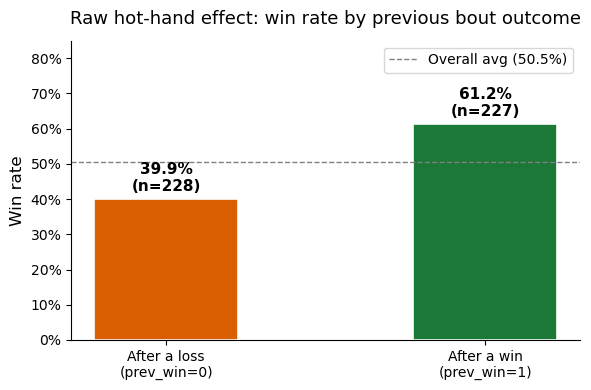


Win rate after loss: 39.9%  |  Win rate after win: 61.2%
Raw difference: +21.3%


In [55]:
# Win rate after a win vs. after a loss (raw hot-hand check)
df_desc = df.dropna(subset=['prev_win'])

win_rates = df_desc.groupby('prev_win')['win'].mean()
counts    = df_desc.groupby('prev_win')['win'].count()

labels = ['After a loss\n(prev_win=0)', 'After a win\n(prev_win=1)']
values = [win_rates[0], win_rates[1]]
ns     = [counts[0],    counts[1]]
colors = ['#d95f02', '#1b7837']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)

for bar, val, n in zip(bars, values, ns):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f'{val:.1%}\n(n={n})',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 0.85)
ax.set_ylabel('Win rate', fontsize=12)
ax.set_title('Raw hot-hand effect: win rate by previous bout outcome', fontsize=13, pad=12)
ax.axhline(df_desc['win'].mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Overall avg ({df_desc["win"].mean():.1%})')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('hot_hand_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nWin rate after loss: {win_rates[0]:.1%}  |  Win rate after win: {win_rates[1]:.1%}')
print(f'Raw difference: {win_rates[1] - win_rates[0]:+.1%}')

In [56]:
# Controlled predicted win-rate comparison
# Hold the same strength_diff values, but compare predictions if prev_win = 0 vs prev_win = 1

X0 = df_model2[['prev_win', 'strength_diff']].copy()
X1 = df_model2[['prev_win', 'strength_diff']].copy()

X0['prev_win'] = 0
X1['prev_win'] = 1

p0 = model.predict_proba(X0)[:, 1].mean()
p1 = model.predict_proba(X1)[:, 1].mean()

print(f"Controlled predicted win rate after loss: {p0:.1%}")
print(f"Controlled predicted win rate after win: {p1:.1%}")
print(f"Controlled difference: {p1 - p0:+.1%}")

Controlled predicted win rate after loss: 48.7%
Controlled predicted win rate after win: 52.1%
Controlled difference: +3.4%


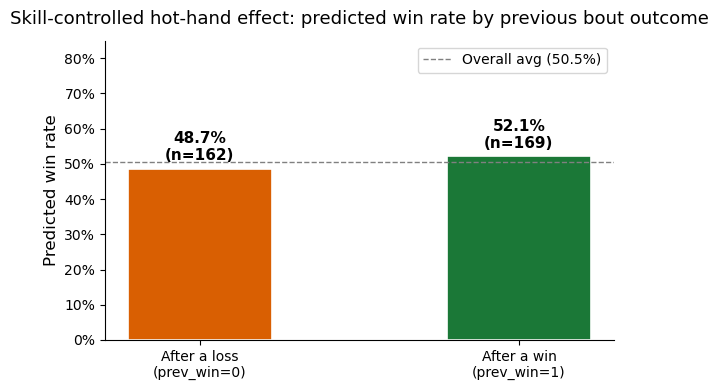


Controlled predicted win rate after loss: 48.7%  |  Controlled predicted win rate after win: 52.1%
Controlled predicted difference: +3.4%


In [58]:
# Skill-controlled predicted win rate after a loss vs. after a win
# Uses the fitted logistic regression model and holds strength_diff constant.

X0 = df_model2[['prev_win', 'strength_diff']].copy()
X1 = df_model2[['prev_win', 'strength_diff']].copy()

X0['prev_win'] = 0
X1['prev_win'] = 1

p0 = model.predict_proba(X0)[:, 1].mean()
p1 = model.predict_proba(X1)[:, 1].mean()

labels = ['After a loss\n(prev_win=0)', 'After a win\n(prev_win=1)']
values = [p0, p1]
ns = [
    (df_model2['prev_win'] == 0).sum(),
    (df_model2['prev_win'] == 1).sum()
]
colors = ['#d95f02', '#1b7837']

# overall average predicted win rate under the actual observed data
overall_pred = model.predict_proba(df_model2[['prev_win', 'strength_diff']])[:, 1].mean()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)

for bar, val, n in zip(bars, values, ns):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f'{val:.1%}\n(n={n})',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylim(0, 0.85)
ax.set_ylabel('Predicted win rate', fontsize=12)
ax.set_title('Skill-controlled hot-hand effect: predicted win rate by previous bout outcome',
             fontsize=13, pad=12)

ax.axhline(overall_pred, color='gray', linestyle='--', linewidth=1,
           label=f'Overall avg ({overall_pred:.1%})')

ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('skill_controlled_predicted_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nControlled predicted win rate after loss: {p0:.1%}  |  Controlled predicted win rate after win: {p1:.1%}')
print(f'Controlled predicted difference: {p1 - p0:+.1%}')